# Heat propagation into wet and dry soil profiles

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice.src_soil import model

In [3]:
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=0.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=0.          # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=1.     # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=0.          # 0. no flow lower BC, 1.0 free draining lowerBC

In [4]:
# Import soil parameters:
from soilice.pars_loam import pars

# Import constants:
from soilice.constants import const

# Convert parameter units into days:
pars['Ks']=pars['Ks']*86400
pars['kappa_org']=pars['kappa_org']*86400
pars['kappa_soil']=pars['kappa_soil']*86400
const['kappa_air']=const['kappa_air']*86400
const['kappa_ice']=const['kappa_ice']*86400
const['kappa_liq']=const['kappa_liq']*86400

In [5]:
# Space grid
zMax=2.
dz=0.01
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,10,0.1) # days
nt=len(t)
dt=t[1]-t[0]

In [6]:
# Boundary conditions - mass and heat fluxes:
jTopBC=2e6  # Specified ground heat flux, if used.

In [7]:
sim=model(opts,rtol=1e-8)
sim.zGrid(np.hstack([0,np.cumsum(dz)]))
sim.tGrid(t[0],t[-1],t[1]-t[0])
sim.setPars(pars)
sim.setConst(const)
sim.BCs(jTopBC=jTopBC)

In [8]:
sim.printOpts()
# Run scenarios with different initial conditions
sim.ICs(psi0=-1,T0=-2.5)
run1=sim.run()

sim.ICs(psi0=-10,T0=-2.5)
run2=sim.run()

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * Solving correct mass bal eqns
     * Vertical flow
     * No cryosuction
     * Included heat advection
     * No conduction on the upper boundary
     * No conduction on the lower boundary
     * No flow
     * Simulating heat transport
     * No (mass) flow lower boundary condition
*************************************************************************

*************************************************************************
     soilice ran successfully!
               runtime:      5.20 seconds
    Mass balance error: -1.00e+02 %
                         2.27e-13 kg
  Energy balance error: -1.36e-04 %
                        -2.69e+01 J
*************************************************************************

*************************************************************************
     soilice ran successfully!
               runtime:      1.17 seconds
    Mass balan

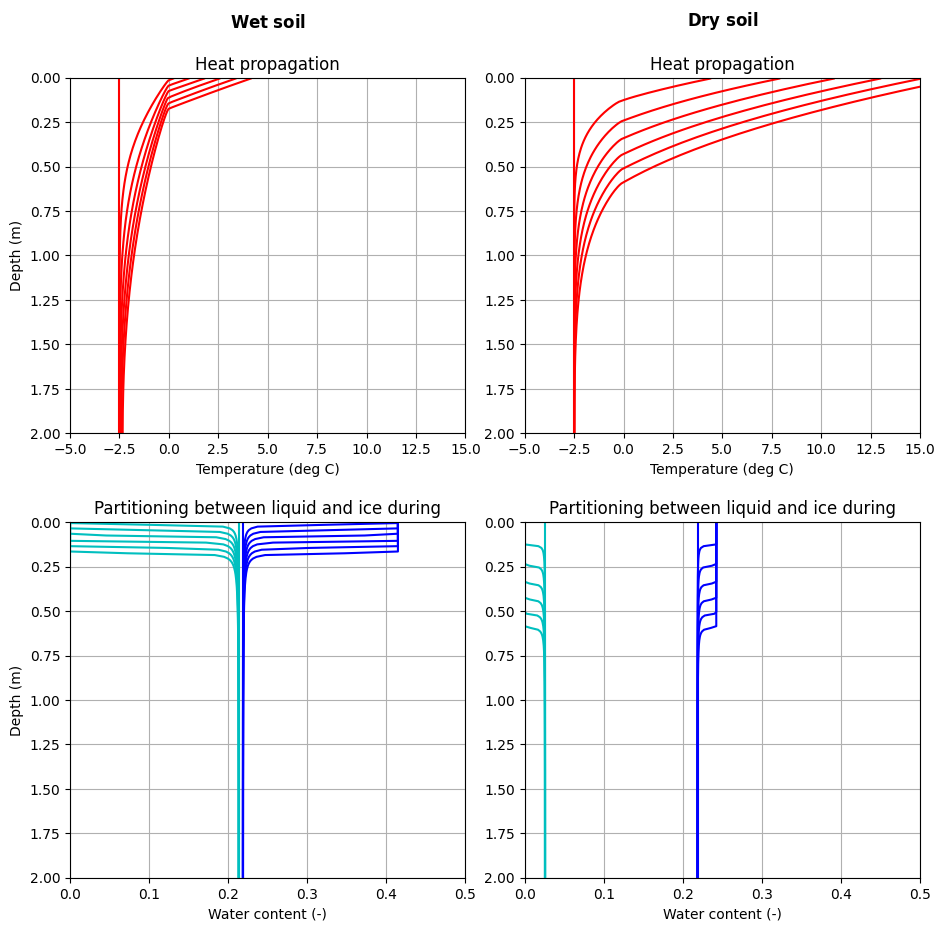

In [9]:
i=np.arange(0,len(t),15)
pl.figure(figsize=(10,10))

pl.subplot(2,2,1)
pl.plot(run1.T[i,:].T,run1.z,'-r')
pl.ylim(2,0)
pl.xlim(-5,15)
pl.grid()
pl.ylabel('Depth (m)')
pl.xlabel('Temperature (deg C)')
pl.title('$\\bf{Wet}$ $\\bf{soil}$\n\nHeat propagation')

pl.subplot(2,2,2)
pl.plot(run2.T[i,:].T,run2.z,'-r')
pl.ylim(2,0)
pl.xlim(-5,15)
pl.grid()
pl.xlabel('Temperature (deg C)')
pl.title('$\\bf{Dry}$ $\\bf{soil}$\n\nHeat propagation')

pl.subplot(2,2,3)
pl.plot(run1.thetaL[i,:].T,run1.z,'-b')
pl.plot(run1.thetaI[i,:].T,run1.z,'-c')
pl.ylim(2,0)
pl.xlim(0, 0.5)
pl.grid()
pl.ylabel('Depth (m)')
pl.xlabel('Water content (-)')
pl.title('Partitioning between liquid and ice during')

pl.subplot(2,2,4)
pl.plot(run2.thetaL[i,:].T,run2.z,'-b')
pl.plot(run2.thetaI[i,:].T,run2.z,'-c')
pl.ylim(2,0)
pl.xlim(0, 0.5)
pl.grid()
pl.xlabel('Water content (-)')
pl.title('Partitioning between liquid and ice during')

pl.gcf().subplots_adjust(
    left=0.1, right=0.95,
    top=0.9, bottom=0.1,
    hspace=0.25, wspace=0.15
)

pl.savefig('figures/01_heatPropagation.png')
pl.show()